In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gauravrawat99/intro-extro-train/train.csv
/kaggle/input/datasets/gauravrawat99/intro-extro-test/test.csv


## EDA

In [25]:
import pandas as pd
train=pd.read_csv('/kaggle/input/datasets/gauravrawat99/intro-extro-train/train.csv')
train

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert
...,...,...,...,...,...,...,...,...,...
18519,18519,3.0,No,7.0,3.0,No,9.0,7.0,Extrovert
18520,18520,1.0,NaN,6.0,7.0,No,6.0,5.0,Extrovert
18521,18521,7.0,Yes,1.0,1.0,Yes,1.0,NaN,Introvert
18522,18522,NaN,Yes,1.0,0.0,Yes,5.0,2.0,Introvert


In [26]:
train['Stage_fear']=train['Stage_fear'].map({'No':0, 'Yes':1})
train['Drained_after_socializing'] = train['Drained_after_socializing'].map({'No':0, 'Yes':1})
train['Personality']=train['Personality'].map({'Introvert':0, 'Extrovert':1})

In [27]:
train

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,0.0,6.0,4.0,0.0,15.0,5.0,1
1,1,1.0,0.0,7.0,3.0,0.0,10.0,8.0,1
2,2,6.0,1.0,1.0,0.0,NaN,3.0,0.0,0
3,3,3.0,0.0,7.0,3.0,0.0,11.0,5.0,1
4,4,1.0,0.0,4.0,4.0,0.0,13.0,NaN,1
...,...,...,...,...,...,...,...,...,...
18519,18519,3.0,0.0,7.0,3.0,0.0,9.0,7.0,1
18520,18520,1.0,NaN,6.0,7.0,0.0,6.0,5.0,1
18521,18521,7.0,1.0,1.0,1.0,1.0,1.0,NaN,0
18522,18522,NaN,1.0,1.0,0.0,1.0,5.0,2.0,0


In [28]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  float64
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  float64
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  int64  
dtypes: float64(7), int64(2)
memory usage: 1.3 MB


In [29]:
train.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

In [30]:
train.describe()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,18524.000000,17334.000000,16631.000000,17344.000000,17058.000000,17375.000000,17470.000000,17260.000000,18524.000000
mean,9261.500000,3.137764,0.241838,5.265106,4.044319,0.233784,7.996737,4.982097,0.739527
std,5347.562529,3.003786,0.428209,2.753359,2.062580,0.423249,4.223484,2.879139,0.438905
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4630.750000,1.000000,0.000000,3.000000,3.000000,0.000000,5.000000,3.000000,0.000000
50%,9261.500000,2.000000,0.000000,5.000000,4.000000,0.000000,8.000000,5.000000,1.000000
75%,13892.250000,4.000000,0.000000,8.000000,6.000000,0.000000,12.000000,7.000000,1.000000
max,18523.000000,11.000000,1.000000,10.000000,7.000000,1.000000,15.000000,10.000000,1.000000


In [31]:
import numpy as np
num_cols=train.select_dtypes(include=[np.number]).columns
num_cols

Index(['id', 'Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')

In [32]:
#Filling Nan values with

#First mode filling
bin_cols=['Stage_fear','Drained_after_socializing']
for cols in bin_cols:
    train[cols].fillna(train[cols].mode()[0], inplace=True)

#Second filling with median
nu_cols=['Time_spent_Alone','Social_event_attendance','Going_outside','Friends_circle_size','Post_frequency']
for cols in nu_cols:
    train[cols].fillna(train[cols].median(), inplace=True)

/tmp/ipykernel_55/3244583734.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[cols].fillna(train[cols].mode()[0], inplace=True)
/tmp/ipykernel_55/3244583734.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [36]:
train.isnull().sum()

id                           0
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [37]:
#Value counts for specific cols
columns=['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality']

for col in columns:
    print(f"\n===== {col} =====")
    
    vc = train[col].value_counts(dropna=False).sort_values()
    
    for category, count in vc.items():
        print(f"{category} : {count}")


===== Time_spent_Alone =====
11.0 : 492
6.0 : 574
9.0 : 574
7.0 : 581
8.0 : 582
10.0 : 587
5.0 : 633
4.0 : 1079
1.0 : 2973
3.0 : 3081
0.0 : 3139
2.0 : 4229

===== Stage_fear =====
1.0 : 4022
0.0 : 14502

===== Social_event_attendance =====
10.0 : 464
1.0 : 978
0.0 : 1055
2.0 : 1063
3.0 : 1703
8.0 : 1945
6.0 : 1984
7.0 : 2031
9.0 : 2063
4.0 : 2073
5.0 : 3165

===== Going_outside =====
1.0 : 1135
2.0 : 1279
0.0 : 1324
7.0 : 2170
6.0 : 2702
3.0 : 2822
5.0 : 2923
4.0 : 4169

===== Drained_after_socializing =====
1.0 : 4062
0.0 : 14462

===== Friends_circle_size =====
0.0 : 467
1.0 : 753
2.0 : 770
3.0 : 866
15.0 : 943
13.0 : 1048
9.0 : 1061
7.0 : 1124
6.0 : 1146
14.0 : 1188
11.0 : 1253
10.0 : 1267
4.0 : 1317
12.0 : 1317
5.0 : 1669
8.0 : 2335

===== Post_frequency =====
10.0 : 677
1.0 : 1214
0.0 : 1272
2.0 : 1291
4.0 : 1688
8.0 : 1734
9.0 : 1744
6.0 : 1767
7.0 : 1827
3.0 : 2258
5.0 : 3052

===== Personality =====
0 : 4825
1 : 13699


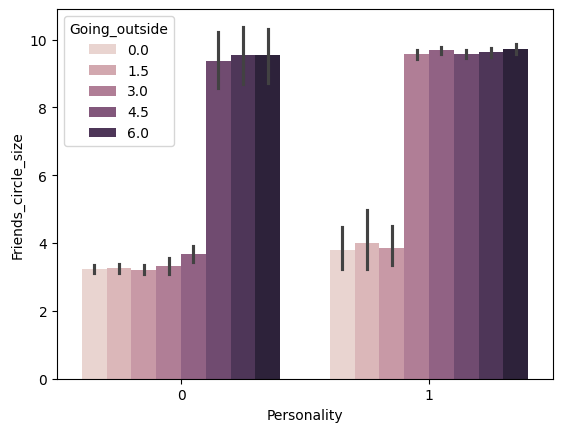

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=train, x='Personality', y='Friends_circle_size', hue='Going_outside')
plt.show()

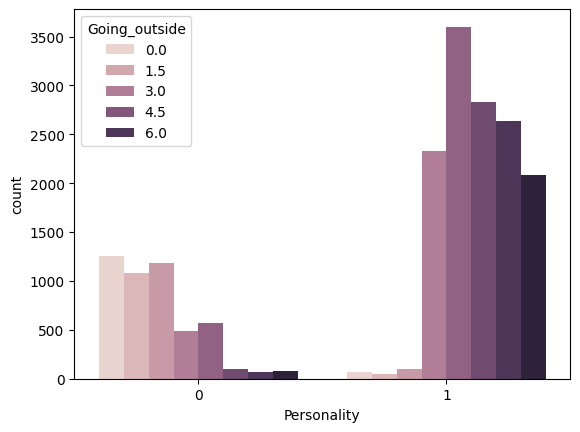

In [41]:
sns.countplot(data=train, x='Personality', hue='Going_outside')
plt.show()

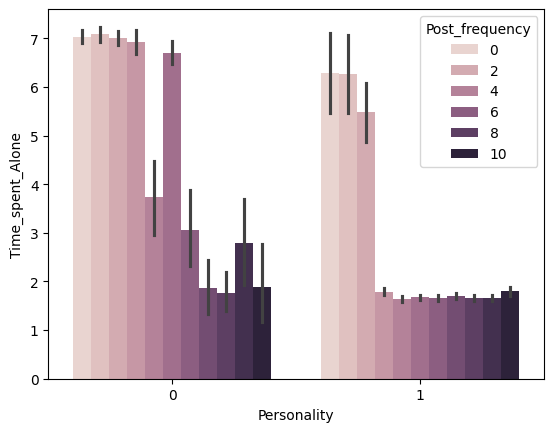

In [43]:
sns.barplot(data=train, x='Personality', y='Time_spent_Alone', hue='Post_frequency')
plt.show()

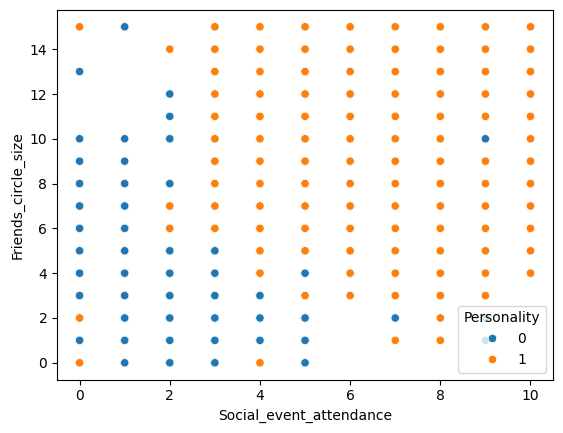

In [46]:
sns.scatterplot(data=train, x='Social_event_attendance', y='Friends_circle_size', hue='Personality')
plt.show()

## Model traininng 

In [48]:
X=train.drop(['id', 'Personality'], axis=1)
y=train['Personality']

In [51]:
X

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,0.0,0.0,6.0,4.0,0.0,15.0,5.0
1,1.0,0.0,7.0,3.0,0.0,10.0,8.0
2,6.0,1.0,1.0,0.0,0.0,3.0,0.0
3,3.0,0.0,7.0,3.0,0.0,11.0,5.0
4,1.0,0.0,4.0,4.0,0.0,13.0,5.0
...,...,...,...,...,...,...,...
18519,3.0,0.0,7.0,3.0,0.0,9.0,7.0
18520,1.0,0.0,6.0,7.0,0.0,6.0,5.0
18521,7.0,1.0,1.0,1.0,1.0,1.0,5.0
18522,2.0,1.0,1.0,0.0,1.0,5.0,2.0


In [61]:
#Feature Engineering
X['social_engagement']=X['Social_event_attendance']+X['Going_outside']+X['Post_frequency']
X['introvert_score']=X['Time_spent_Alone']+X['Stage_fear']+X['Drained_after_socializing']
X['social_vs_alone']=X['social_engagement'] / (X['Time_spent_Alone'] + 1)
X['friends_per_event']=X['Friends_circle_size'] / (X['Social_event_attendance'] + 1)
X['online_vs_offline']=X['Post_frequency'] / (X['Going_outside'] + 1)

X['alone_time_level']=pd.cut(X['Time_spent_Alone'], bins=[0,2,5,8,10], labels=[0,1,2,3])
X['alone_time_level']=X['alone_time_level'].fillna(X['alone_time_level'].mode()[0])
X['alone_time_level']=X['alone_time_level'].astype(int)

In [62]:
X

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,social_engagement,introver_score,social_vs_alone,friends_per_event,online_vs_offline,introvert_score,alone_time_level
0,0.0,0.0,6.0,4.0,0.0,15.0,5.0,15.0,0.0,15.000000,2.142857,1.000,0.0,0
1,1.0,0.0,7.0,3.0,0.0,10.0,8.0,18.0,1.0,9.000000,1.250000,2.000,1.0,0
2,6.0,1.0,1.0,0.0,0.0,3.0,0.0,1.0,7.0,0.142857,1.500000,0.000,7.0,2
3,3.0,0.0,7.0,3.0,0.0,11.0,5.0,15.0,3.0,3.750000,1.375000,1.250,3.0,1
4,1.0,0.0,4.0,4.0,0.0,13.0,5.0,13.0,1.0,6.500000,2.600000,1.000,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18519,3.0,0.0,7.0,3.0,0.0,9.0,7.0,17.0,3.0,4.250000,1.125000,1.750,3.0,1
18520,1.0,0.0,6.0,7.0,0.0,6.0,5.0,18.0,1.0,9.000000,0.857143,0.625,1.0,0
18521,7.0,1.0,1.0,1.0,1.0,1.0,5.0,7.0,9.0,0.875000,0.500000,2.500,9.0,2
18522,2.0,1.0,1.0,0.0,1.0,5.0,2.0,3.0,4.0,1.000000,2.500000,2.000,4.0,0


In [67]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

param_grid={'n_estimators':[10,25,50,75,100],
           'max_depth':[4,5,6,7,8]}

grid_search_rfc=GridSearchCV(RandomForestClassifier(n_jobs=-1), param_grid=param_grid, cv=5).fit(X_train, y_train)

grid_pred=grid_search_rfc.predict(X_val)
grid_pred_prob=grid_search_rfc.predict_proba(X_val)[:,1]

print("Best params: ", grid_search_rfc.best_params_)
print('AUC score: ', roc_auc_score(y_val, grid_pred_prob))
print('Confusion matrix:\n', confusion_matrix(y_val, grid_pred))
print('Classification reprot:\n', classification_report(y_val, grid_pred))

Best params:  {'max_depth': 4, 'n_estimators': 25}
AUC score:  0.965180651516967
Confusion matrix:
 [[ 687   48]
 [  35 2009]]
Classification reprot:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       735
           1       0.98      0.98      0.98      2044

    accuracy                           0.97      2779
   macro avg       0.96      0.96      0.96      2779
weighted avg       0.97      0.97      0.97      2779



In [68]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)
param_grid={'n_estimators':[10,25,50,75,100],
           'max_depth':[4,5,6,7,8],
           'learning_rate':[0.02,0.03,0.04,0.05,0.06]}

grid_search_xgbc=GridSearchCV(XGBClassifier(n_jobs=-1), param_grid=param_grid, cv=5).fit(X_train, y_train)

grid_pred=grid_search_xgbc.predict(X_val)
grid_pred_prob=grid_search_xgbc.predict_proba(X_val)[:,1]

print("Best params: ", grid_search_xgbc.best_params_)
print('AUC score: ', roc_auc_score(y_val, grid_pred_prob))
print('Confusion matrix:\n', confusion_matrix(y_val, grid_pred))
print('Classification reprot:\n', classification_report(y_val, grid_pred))

Best params:  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
AUC score:  0.9672597414699735
Confusion matrix:
 [[ 688   47]
 [  33 2011]]
Classification reprot:
               precision    recall  f1-score   support

           0       0.95      0.94      0.95       735
           1       0.98      0.98      0.98      2044

    accuracy                           0.97      2779
   macro avg       0.97      0.96      0.96      2779
weighted avg       0.97      0.97      0.97      2779



## Now on test data

In [74]:
test=pd.read_csv('/kaggle/input/datasets/gauravrawat99/intro-extro-test/test.csv')
test

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,18524,3.0,No,7.0,4.0,No,6.0,NaN
1,18525,NaN,Yes,0.0,0.0,Yes,5.0,1.0
2,18526,3.0,No,5.0,6.0,No,15.0,9.0
3,18527,3.0,No,4.0,4.0,No,5.0,6.0
4,18528,9.0,Yes,1.0,2.0,Yes,1.0,1.0
...,...,...,...,...,...,...,...,...
6170,24694,3.0,No,5.0,5.0,No,9.0,6.0
6171,24695,8.0,Yes,2.0,1.0,Yes,0.0,0.0
6172,24696,2.0,No,4.0,3.0,No,9.0,7.0
6173,24697,3.0,No,4.0,4.0,No,11.0,9.0


In [75]:
test.isnull().sum()

id                             0
Time_spent_Alone             425
Stage_fear                   598
Social_event_attendance      397
Going_outside                466
Drained_after_socializing    432
Friends_circle_size          350
Post_frequency               408
dtype: int64

In [76]:
test['Stage_fear']=test['Stage_fear'].map({'No':0, 'Yes':1})
test['Drained_after_socializing'] = test['Drained_after_socializing'].map({'No':0, 'Yes':1})
# test['Personality']=test['Personality'].map({'Introvert':0, 'Extrovert':1})

In [77]:
test

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,18524,3.0,0.0,7.0,4.0,0.0,6.0,NaN
1,18525,NaN,1.0,0.0,0.0,1.0,5.0,1.0
2,18526,3.0,0.0,5.0,6.0,0.0,15.0,9.0
3,18527,3.0,0.0,4.0,4.0,0.0,5.0,6.0
4,18528,9.0,1.0,1.0,2.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...
6170,24694,3.0,0.0,5.0,5.0,0.0,9.0,6.0
6171,24695,8.0,1.0,2.0,1.0,1.0,0.0,0.0
6172,24696,2.0,0.0,4.0,3.0,0.0,9.0,7.0
6173,24697,3.0,0.0,4.0,4.0,0.0,11.0,9.0


In [80]:
#Filling Nan values with

#First mode filling
bin_cols=['Stage_fear','Drained_after_socializing']
for cols in bin_cols:
    test[cols].fillna(test[cols].mode()[0], inplace=True)

#Second filling with median
nu_cols=['Time_spent_Alone','Social_event_attendance','Going_outside','Friends_circle_size','Post_frequency']
for cols in nu_cols:
    test[cols].fillna(test[cols].median(), inplace=True)

/tmp/ipykernel_55/3283913902.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[cols].fillna(test[cols].mode()[0], inplace=True)
/tmp/ipykernel_55/3283913902.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [87]:
test_ID=test['id']

test['social_engagement']=test['Social_event_attendance']+test['Going_outside']+test['Post_frequency']
test['introvert_score']=test['Time_spent_Alone']+test['Stage_fear']+test['Drained_after_socializing']
test['social_vs_alone']=test['social_engagement'] / (test['Time_spent_Alone'] + 1)
test['friends_per_event']=test['Friends_circle_size'] / (test['Social_event_attendance'] + 1)
test['online_vs_offline']=test['Post_frequency'] / (test['Going_outside'] + 1)

test['alone_time_level']=pd.cut(test['Time_spent_Alone'], bins=[0,2,5,8,10], labels=[0,1,2,3])
test['alone_time_level']=test['alone_time_level'].fillna(test['alone_time_level'].mode()[0])
test['alone_time_level']=test['alone_time_level'].astype(int)

In [89]:
from xgboost import XGBClassifier

test=test[X.columns]

test_probs=grid_search_xgbc.predict(test)

print(test_probs)

[1 0 1 ... 1 1 0]


In [91]:
import pandas as pd

submission = pd.DataFrame({
    "id": test_ID,
    "Personality": pd.Series(test_probs).map({0: "Introvert", 1:'Extrovert'})
})

submission.to_csv("submission.csv", index=False)

print("submission.csv saved!")
print(f"Shape           : {submission.shape}")
print(f"Mean prediction : {submission['Personality'].mean():.5f}")
print(f"Std  prediction : {submission['Personality'].std():.5f}")

display(submission.head(20))
print(submission.isnull().sum())

submission.csv saved!
Shape           : (6175, 2)


TypeError: Could not convert string '...' to numeric